# Initial Data Loading

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the CSV file
# Assuming the file is directly in your Google Drive 'My Drive' folder
csv_path = '/content/drive/MyDrive/ML1 - Final Project/employee_attrition_data.csv'


# Import the CSV file into a pandas DataFrame
try:
    df = pd.read_csv(csv_path)
    print("CSV file imported successfully!")
    print(f"DataFrame shape: {df.shape}")
    print(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_path}' was not found. Please ensure it is in your Google Drive 'My Drive' folder.")
except Exception as e:
    print(f"An error occurred: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV file imported successfully!
DataFrame shape: (1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences 

### **Initial Data Cleaning**

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [ ]:
clean_df = df

# 1. Strip whitespace from column names
clean_df.columns = clean_df.columns.str.strip()

In [ ]:
# 2. Fill any blanks (median, other logic, etc)

# Impute missing age as Age = TotalWorkingYears + 22 (graduating age)
# If any Age still missing after this, median-impute them
mask = clean_df["Age"].isna() & clean_df["TotalWorkingYears"].notna()
clean_df.loc[mask, "Age"] = clean_df.loc[mask, "TotalWorkingYears"] + 22

age_median = clean_df["Age"].median()
clean_df["Age"] = clean_df["Age"].fillna(age_median)

# Impute missing business travel as BusinessTravel = most frequent BusinessTravel
# for: 1) JobRole and 2) Department (if JobRole missing)
# If still blank, use the most common BusinessTravel in dataset
predictors = ["JobRole", "Department"]

for col in predictors:
    if {"BusinessTravel", col}.issubset(clean_df.columns):
        mode_map = (
            clean_df
            .dropna(subset=["BusinessTravel", col])
            .groupby(col)["BusinessTravel"]
            .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        )
        mask = clean_df["BusinessTravel"].isna() & clean_df[col].notna()
        clean_df.loc[mask, "BusinessTravel"] = clean_df.loc[mask, col].map(mode_map)

if "BusinessTravel" in clean_df.columns:
    global_bt_mode = clean_df["BusinessTravel"].dropna().mode()
    if not global_bt_mode.empty:
        clean_df["BusinessTravel"] = clean_df["BusinessTravel"].fillna(global_bt_mode.iloc[0])


# Impute missing DailyRate as DailyRate = HourlyRate * 8 hours
if {"DailyRate", "HourlyRate"}.issubset(clean_df.columns):
    mask = clean_df["DailyRate"].isna() & clean_df["HourlyRate"].notna()
    clean_df.loc[mask, "DailyRate"] = clean_df.loc[mask, "HourlyRate"] * 8

# Impute missing DistanceFromHome = median DistanceFromHome
# for: 1) JobRole, 2) Department, 3) BusinessTravel
# If still blank, use the median DistanceFromHome from dataset
predictors = ["JobRole", "Department", "BusinessTravel"]

for col in predictors:
    if {"DistanceFromHome", col}.issubset(clean_df.columns):
        dist_map = (
            clean_df
            .dropna(subset=["DistanceFromHome", col])
            .groupby(col)["DistanceFromHome"]
            .median()
        )
        mask = clean_df["DistanceFromHome"].isna() & clean_df[col].notna()
        clean_df.loc[mask, "DistanceFromHome"] = (
            clean_df.loc[mask, col].map(dist_map)
        )

if "DistanceFromHome" in clean_df.columns:
    clean_df["DistanceFromHome"] = clean_df["DistanceFromHome"].fillna(
        clean_df["DistanceFromHome"].median()
    )

# Impute missing MaritalStatus = median DistanceFromHome
# for: 1) JobRole, 2) Department, 3) BusinessTravel
# If still blank, use the median DistanceFromHome from dataset
import pandas as pd

# Create AgeBand if needed
if "Age" in clean_df.columns:
    clean_df["AgeBand"] = pd.cut(
        clean_df["Age"],
        bins=[0, 25, 35, 45, 55, 100],
        labels=["<=25", "26-35", "36-45", "46-55", "55+"]
    )

if {"MaritalStatus", "AgeBand"}.issubset(clean_df.columns):
    ms_by_ageband = (
        clean_df
        .dropna(subset=["MaritalStatus", "AgeBand"])
        .groupby("AgeBand")["MaritalStatus"]
        .agg(lambda x: x.mode().iloc[0])
    )

    mask = clean_df["MaritalStatus"].isna() & clean_df["AgeBand"].notna()
    clean_df.loc[mask, "MaritalStatus"] = (
        clean_df.loc[mask, "AgeBand"].map(ms_by_ageband)
    )


/tmp/ipython-input-674937929.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("AgeBand")["MaritalStatus"]


In [ ]:
# 3. Change all categorical columns into numeric

# Attrition -> Yes = 0, No = 1
clean_df["Attrition"] = clean_df["Attrition"].astype(str).str.strip().map({"Yes": 1, "No": 0}).astype("Int64")

# Gender -> isFemale
if "Gender" in clean_df.columns:
    clean_df["Gender"] = clean_df["Gender"].astype(str).str.strip()
    clean_df["isFemale"] = (clean_df["Gender"] == "Female").astype(float)
    clean_df = clean_df.drop(columns=["Gender"])

# OverTime -> isOverTime
if "OverTime" in clean_df.columns:
    clean_df["OverTime"] = clean_df["OverTime"].astype(str).str.strip()
    clean_df["isOverTime"] = (clean_df["OverTime"] == "Yes").astype(float)
    clean_df = clean_df.drop(columns=["OverTime"])

# BusinessTravel: Non-Travel, Travel_Rarely, Travel_Frequently
if "BusinessTravel" in clean_df.columns:
    clean_df["BusinessTravel"] = clean_df["BusinessTravel"].astype(str).str.strip()
    bt_map = {
        "Non-Travel": 0,
        "Travel_Rarely": 1,
        "Travel_Frequently": 2
    }
    clean_df["BusinessTravel"] = clean_df["BusinessTravel"].map(bt_map).astype(float)

# Department: Sales, Research & Development, Human Resources
if "Department" in clean_df.columns:
    clean_df["Department"] = clean_df["Department"].astype(str).str.strip()
    dept_map = {
        "Human Resources": 0,
        "Research & Development": 1,
        "Sales": 2
    }
    clean_df["Department"] = clean_df["Department"].map(dept_map).astype(float)

# EducationField (e.g., Medical, Life Sciences, Technical)
if "EducationField" in clean_df.columns:
    clean_df["EducationField"] = clean_df["EducationField"].astype(str).str.strip()
    ef_vals = sorted(clean_df["EducationField"].dropna().unique())
    ef_map = {val: i for i, val in enumerate(ef_vals)}
    clean_df["EducationField"] = clean_df["EducationField"].map(ef_map).astype(float)

# JobRole (e.g., Sales Executive, Human Resources, Research Scientist)
if "JobRole" in clean_df.columns:
    clean_df["JobRole"] = clean_df["JobRole"].astype(str).str.strip()
    jr_vals = sorted(clean_df["JobRole"].dropna().unique())
    jr_map = {val: i for i, val in enumerate(jr_vals)}
    clean_df["JobRole"] = clean_df["JobRole"].map(jr_map).astype(float)

# MaritalStatus: Divorced, Married, Single
if "MaritalStatus" in clean_df.columns:
    clean_df["MaritalStatus"] = clean_df["MaritalStatus"].astype(str).str.strip()
    marital_map = {
        "Divorced": 0,
        "Married": 1,
        "Single": 2
    }
    clean_df["MaritalStatus"] = clean_df["MaritalStatus"].map(marital_map).astype(float)


In [ ]:
# 4. Convert obvious numeric columns
numeric_cols = [
    "Age", "DailyRate", "DistanceFromHome", "Education", "EmployeeCount",
    "EmployeeNumber", "EnvironmentSatisfaction", "HourlyRate",
    "JobInvolvement", "JobLevel", "JobSatisfaction", "MonthlyIncome",
    "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike",
    "PerformanceRating", "RelationshipSatisfaction", "StandardHours",
    "StockOptionLevel", "TotalWorkingYears", "TrainingTimesLastYear",
    "WorkLifeBalance", "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager",
    "BusinessTravel", "Department", "EducationField", "JobRole",
    "MaritalStatus", "isFemale", "isOverTime", "Attrition"
]
numeric_cols = [c for c in numeric_cols if c in clean_df.columns]

for c in numeric_cols:
    clean_df[c] = pd.to_numeric(clean_df[c], errors="coerce")

In [ ]:
# 5. Drop constant / obvious columns
to_drop = [
    "EmployeeCount", # constant 1 in dataset
    "Over18", # constant 'Y' in dataset
    "StandardHours", # constant 80 in dataset
    "EmployeeNumber" # ID only - adds no value
    ]
clean_df = clean_df.drop(columns=to_drop)

In [ ]:
# Cleaned dataset
clean_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeBand,isFemale,isOverTime
0,41,1,1.0,1102,2.0,1,2,1.0,2,94,3,2,7.0,4,2.0,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,36-45,1.0,1.0
1,49,0,2.0,279,1.0,8,1,1.0,3,61,2,2,6.0,2,1.0,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,46-55,0.0,0.0
2,37,1,1.0,1373,1.0,2,2,4.0,4,92,2,1,2.0,3,2.0,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,36-45,0.0,1.0
3,33,0,2.0,1392,1.0,3,4,1.0,4,56,3,1,6.0,3,1.0,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,26-35,1.0,1.0
4,27,0,1.0,591,1.0,2,1,3.0,1,40,3,1,2.0,2,1.0,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,26-35,0.0,0.0


In [ ]:
# Double check for any more missing values
clean_df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
HourlyRate,0


In [ ]:
output_csv_path = '/content/drive/MyDrive/ML1 - Final Project/employee_attrition_cleaned.csv'
clean_df.to_csv(output_csv_path, index=False)
print(f"Cleaned data saved successfully to: {output_csv_path}")

Cleaned data saved successfully to: /content/drive/MyDrive/ML1 - Final Project/employee_attrition_cleaned.csv


# **Exploratory Data Analysis (EDA)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Load cleaned dataset
file_path = "/content/drive/MyDrive/ML1 - Final Project/employee_attrition_cleaned.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1470, 32)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeBand,isFemale,isOverTime
0,41,1,1.0,1102,2.0,1,2,1.0,2,94,3,2,7.0,4,2.0,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,36-45,1.0,1.0
1,49,0,2.0,279,1.0,8,1,1.0,3,61,2,2,6.0,2,1.0,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,46-55,0.0,0.0
2,37,1,1.0,1373,1.0,2,2,4.0,4,92,2,1,2.0,3,2.0,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,36-45,0.0,1.0
3,33,0,2.0,1392,1.0,3,4,1.0,4,56,3,1,6.0,3,1.0,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,26-35,1.0,1.0
4,27,0,1.0,591,1.0,2,1,3.0,1,40,3,1,2.0,2,1.0,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,26-35,0.0,0.0


#### 1. Dataset Overview

In [ ]:
print("Dataset Shape")
print(df.shape)  # Rows = employees, Columns = features

print("\nData Types")
print(df.dtypes)

print("\nSummary Statistics")
df.describe().T  # Transposed for readability — shows mean, std, min/max for all numeric cols

Dataset Shape
(1470, 32)

Data Types
Age                           int64
Attrition                     int64
BusinessTravel              float64
DailyRate                     int64
Department                  float64
DistanceFromHome              int64
Education                     int64
EducationField              float64
EnvironmentSatisfaction       int64
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                     float64
JobSatisfaction               int64
MaritalStatus               float64
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StockOptionLevel              int64
TotalWorkingYears             int64
TrainingTimesLastYear         int64
WorkLifeBalance               int64
YearsAtCompany                int64
YearsInCurrentRole         

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
Attrition,1470.0,0.161224,0.367863,0.0,0.0,0.0,0.00,1.0
BusinessTravel,1470.0,1.086395,0.532170,0.0,1.0,1.0,1.00,2.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
Department,1470.0,1.260544,0.527792,0.0,1.0,1.0,2.00,2.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EducationField,1470.0,2.247619,1.331369,0.0,1.0,2.0,3.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0


In [ ]:
# Skewness & Kurtosis Analysis
from scipy.stats import skew, kurtosis

numeric_df_early = df.select_dtypes(include=[np.number])

skew_kurt = pd.DataFrame({
    'Skewness': numeric_df_early.apply(skew),
    'Kurtosis': numeric_df_early.apply(kurtosis)
}).round(3).sort_values('Skewness', ascending=False)

# Flag features that likely need transformation
skew_kurt['High Skew (>|1|)'] = skew_kurt['Skewness'].abs() > 1
skew_kurt['Heavy Tails (>3)'] = skew_kurt['Kurtosis'] > 3

print("Skewness & Kurtosis of Numeric Features")
print(skew_kurt.to_string())

# Highlight the features that need attention
flagged = skew_kurt[skew_kurt['High Skew (>|1|)'] | skew_kurt['Heavy Tails (>3)']]
print(f"\n  {len(flagged)} features flagged for potential transformation:")
print(flagged[['Skewness', 'Kurtosis']].to_string())

Skewness & Kurtosis of Numeric Features
                          Skewness  Kurtosis  High Skew (>|1|)  Heavy Tails (>3)
YearsSinceLastPromotion      1.982     3.596              True              True
PerformanceRating            1.920     1.686              True             False
Attrition                    1.842     1.395              True             False
YearsAtCompany               1.763     3.918              True              True
MonthlyIncome                1.368     0.998              True             False
TotalWorkingYears            1.116     0.911              True             False
NumCompaniesWorked           1.025     0.006              True             False
JobLevel                     1.024     0.394              True             False
StockOptionLevel             0.968     0.359             False             False
isOverTime                   0.964    -1.072             False             False
DistanceFromHome             0.957    -0.228             False       

#### 2. Key Variable Distribution

*Understanding the spread of important features helps us spot skewness, imbalances, or anomalies that could affect model performance.*

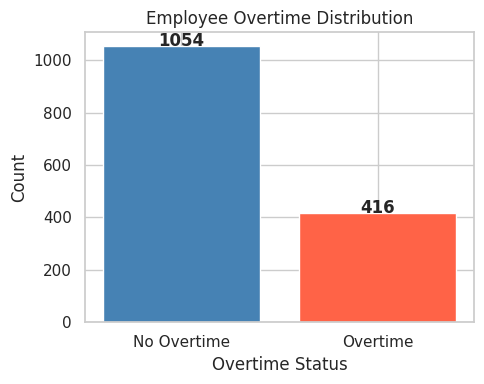

Overtime rate: 28.3% of employees work overtime


In [ ]:
# 2a. Overtime Distribution
overtime_counts = df['isOverTime'].value_counts()
labels = ['No Overtime', 'Overtime']
plt.figure(figsize=(5, 4))
plt.bar(labels, overtime_counts.values, color=['steelblue', 'tomato'])
plt.title('Employee Overtime Distribution')
plt.ylabel('Count')
plt.xlabel('Overtime Status')
for i, v in enumerate(overtime_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Overtime rate: {overtime_counts[1] / len(df):.1%} of employees work overtime")

/tmp/ipython-input-1843095460.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='JobSatisfaction', data=df, palette='Blues_d')


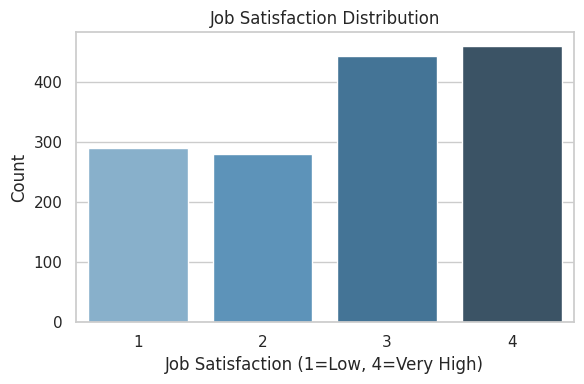

In [ ]:
# 2b. Job Satisfaction Distribution
# Satisfaction scores (1=Low to 4=Very High) are strong attrition signals.
plt.figure(figsize=(6, 4))
sns.countplot(x='JobSatisfaction', data=df, palette='Blues_d')
plt.title('Job Satisfaction Distribution')
plt.xlabel('Job Satisfaction (1=Low, 4=Very High)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

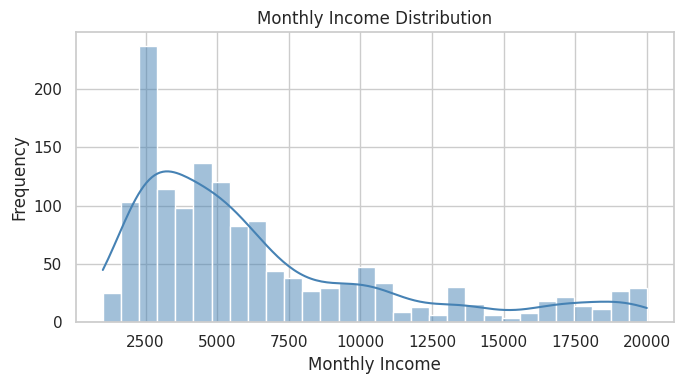

Median Monthly Income: $4,919
Income is right-skewed — a log transform may be useful during modeling.


In [ ]:
# 2c. Monthly Income Distribution
# Income is often linked to attrition — lower earners tend to leave more.
plt.figure(figsize=(7, 4))
sns.histplot(df['MonthlyIncome'], bins=30, kde=True, color='steelblue')
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print(f"Median Monthly Income: ${df['MonthlyIncome'].median():,.0f}")
print(f"Income is right-skewed — a log transform may be useful during modeling.")

/tmp/ipython-input-2669003381.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='AgeBand', data=df, order=age_order_present, palette='viridis')


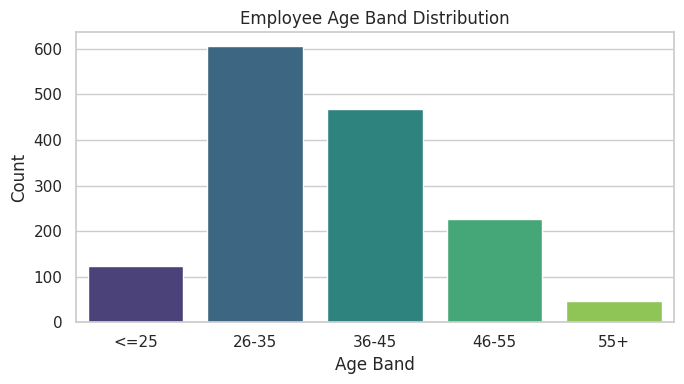

In [ ]:
# 2d. Age Distribution by Age Band
# Younger employees are typically more mobile; age bands show workforce composition.
plt.figure(figsize=(7, 4))
age_order = ['<=25', '26-35', '36-45', '46-55', '55+']
age_order_present = [a for a in age_order if a in df['AgeBand'].values]
sns.countplot(x='AgeBand', data=df, order=age_order_present, palette='viridis')
plt.title('Employee Age Band Distribution')
plt.xlabel('Age Band')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

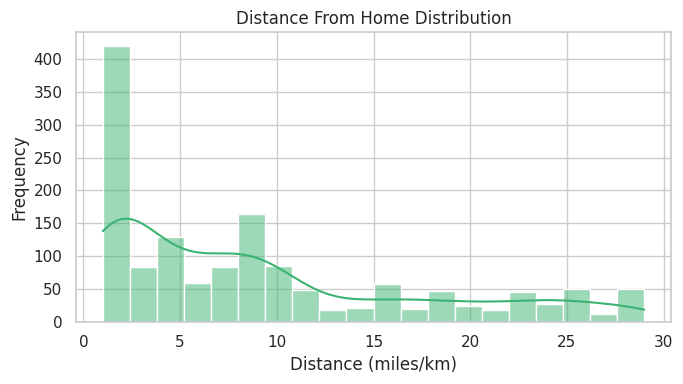

In [ ]:
# 2e. Distance From Home Distribution
# Longer commutes are associated with higher attrition risk.
plt.figure(figsize=(7, 4))
sns.histplot(df['DistanceFromHome'], bins=20, kde=True, color='mediumseagreen')
plt.title('Distance From Home Distribution')
plt.xlabel('Distance (miles/km)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

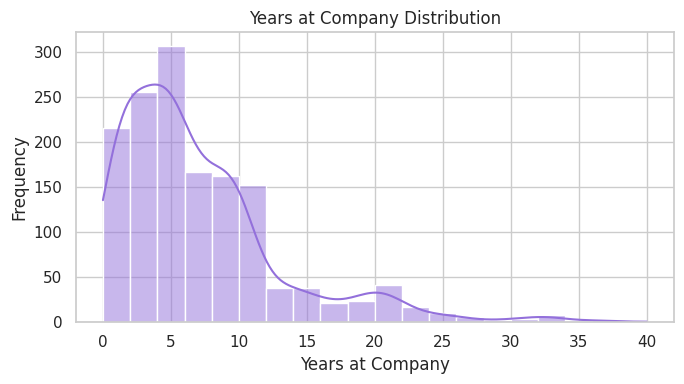

Median tenure: 5.0 years — right skew expected.


In [ ]:
# 3f. Years At Company Distribution
# Tenure distribution reveals early-career attrition risk vs. veteran stability.
plt.figure(figsize=(7, 4))
sns.histplot(df['YearsAtCompany'], bins=20, kde=True, color='mediumpurple')
plt.title('Years at Company Distribution')
plt.xlabel('Years at Company')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
print(f"Median tenure: {df['YearsAtCompany'].median()} years — right skew expected.")

#### 3. Multivariate Relationships

*We explore relationships between known high-signal features to understand the employee population. These patterns inform which features to prioritize in our predictive model.*

/tmp/ipython-input-1368982214.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='JobLevel', y='MonthlyIncome', data=df, palette='coolwarm')


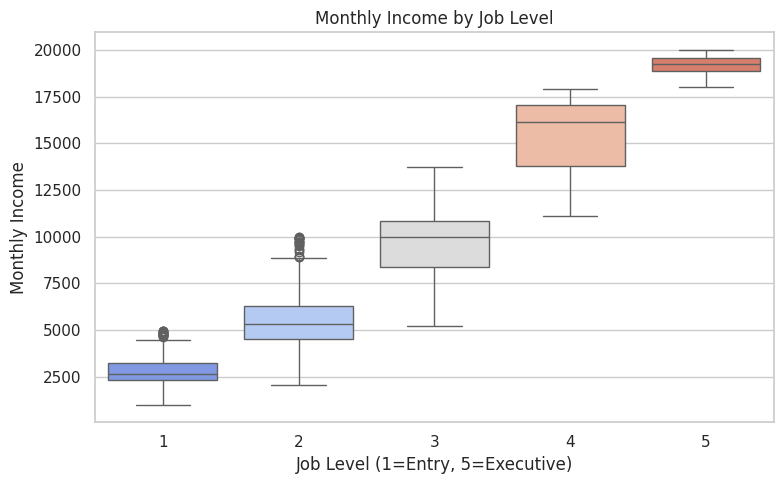

In [ ]:
# 3a. Income by Job Level
# Job Level is a proxy for seniority; lower levels typically earn less and leave more.
plt.figure(figsize=(8, 5))
sns.boxplot(x='JobLevel', y='MonthlyIncome', data=df, palette='coolwarm')
plt.title('Monthly Income by Job Level')
plt.xlabel('Job Level (1=Entry, 5=Executive)')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.show()

/tmp/ipython-input-1150154490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=ax, palette='Blues_d')
/tmp/ipython-input-1150154490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=ax, palette='Blues_d')
/tmp/ipython-input-1150154490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=ax, palette='Blues_d')
/tmp/ipython-input-1150154490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `

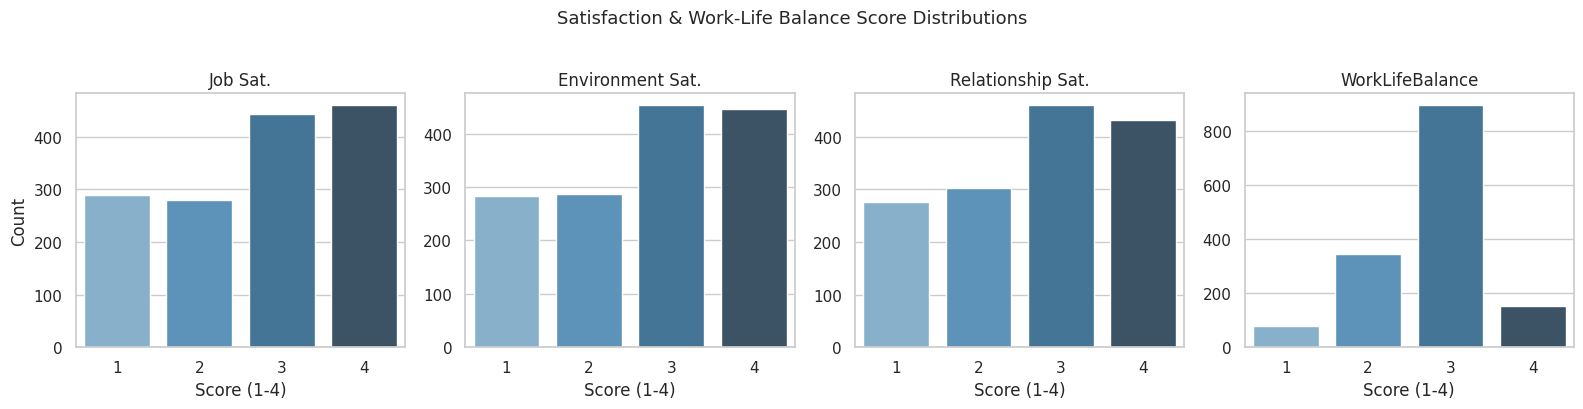

In [ ]:
# 3b. Satisfaction Scores Overview
# Compare all satisfaction-related metrics side by side.
satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
                     'RelationshipSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, satisfaction_cols):
    sns.countplot(x=col, data=df, ax=ax, palette='Blues_d')
    ax.set_title(col.replace('Satisfaction', ' Sat.'))
    ax.set_xlabel('Score (1-4)')
    ax.set_ylabel('Count' if ax == axes[0] else '')
plt.suptitle('Satisfaction & Work-Life Balance Score Distributions', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipython-input-3318342093.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='JobLevel', y='isOverTime', data=overtime_by_level, palette='Reds_d')


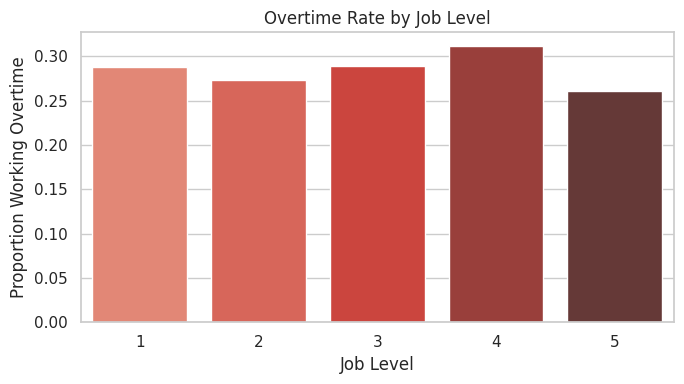

In [ ]:
# 3c. Overtime vs. Job Level
# Are overtime-heavy employees concentrated in certain job levels?
plt.figure(figsize=(7, 4))
overtime_by_level = df.groupby('JobLevel')['isOverTime'].mean().reset_index()
sns.barplot(x='JobLevel', y='isOverTime', data=overtime_by_level, palette='Reds_d')
plt.title('Overtime Rate by Job Level')
plt.xlabel('Job Level')
plt.ylabel('Proportion Working Overtime')
plt.tight_layout()
plt.show()

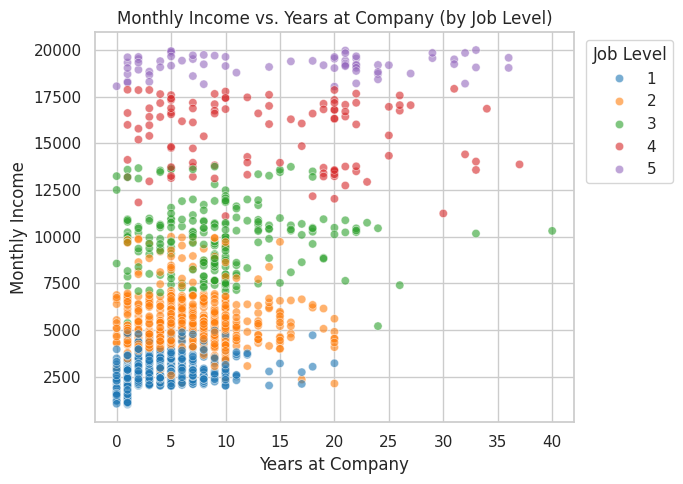

In [ ]:
# 3d. Income vs. Years at Company
# Do long-tenure employees earn more? Flat income growth can cause attrition.
plt.figure(figsize=(7, 5))
sns.scatterplot(x='YearsAtCompany', y='MonthlyIncome', hue='JobLevel',
                data=df, palette='tab10', alpha=0.6)
plt.title('Monthly Income vs. Years at Company (by Job Level)')
plt.xlabel('Years at Company')
plt.ylabel('Monthly Income')
plt.legend(title='Job Level', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3860847919.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='YearsSinceLastPromotion', y='JobRoleLabel', data=avg_promo,


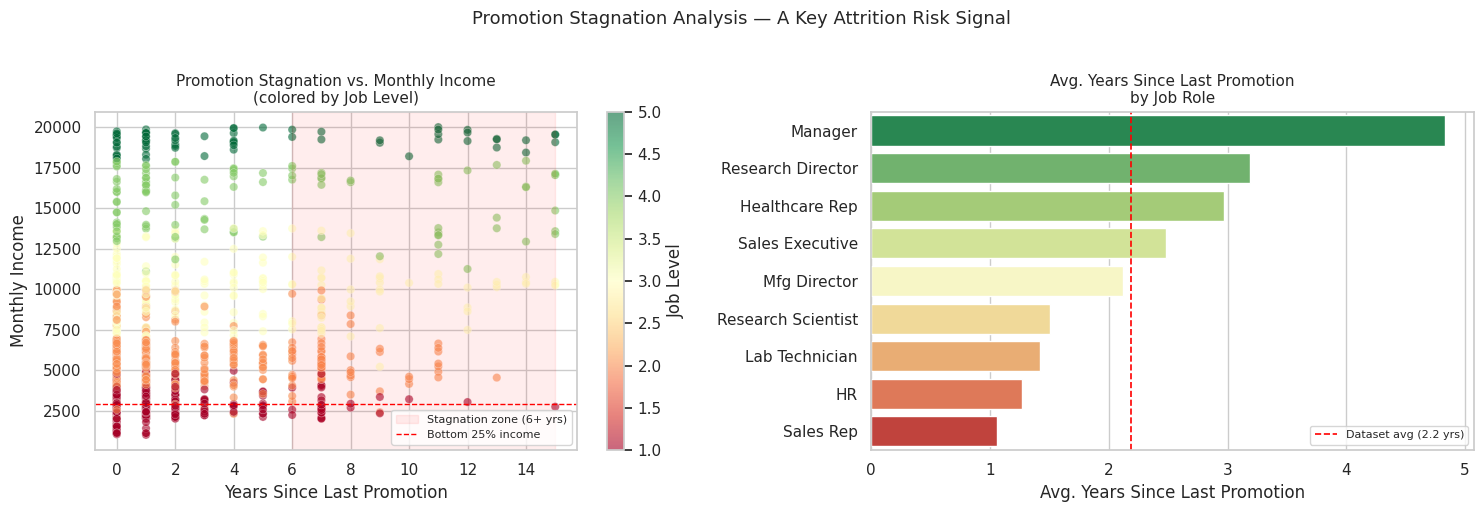

Employees with 6+ years since last promotion: 215 (14.6%)
Of those, earning below 25th income percentile: 18 employees
→ These employees represent the highest-priority intervention targets for HR.


In [ ]:
# 3e. Promotion Stagnation vs. Income (by job level)
# Employees with long stints since their last promotion AND flat income
# are classic flight risks — they feel undervalued and career-stalled.
# This plot surfaces that "stuck employee" profile which HR should prioritize.

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left plot: Scatterplot of promotion stagnation vs. income
scatter = axes[0].scatter(
    df['YearsSinceLastPromotion'],
    df['MonthlyIncome'],
    c=df['JobLevel'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.3
)
axes[0].set_title('Promotion Stagnation vs. Monthly Income\n(colored by Job Level)', fontsize=11)
axes[0].set_xlabel('Years Since Last Promotion')
axes[0].set_ylabel('Monthly Income')
plt.colorbar(scatter, ax=axes[0], label='Job Level')

# Annotate the danger zone: long stagnation + low income
axes[0].axvspan(6, df['YearsSinceLastPromotion'].max(), alpha=0.07, color='red', label='Stagnation zone (6+ yrs)')
axes[0].axhline(df['MonthlyIncome'].quantile(0.25), color='red', linestyle='--', linewidth=1, label='Bottom 25% income')
axes[0].legend(fontsize=8)

# Right plot: Average years since promotion by Job Role
avg_promo = (
    df.groupby('JobRole')['YearsSinceLastPromotion']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Decode JobRole numeric back to labels for readability
jobrole_map = {
    0: 'Healthcare Rep', 1: 'HR', 2: 'Lab Technician',
    3: 'Manager', 4: 'Mfg Director', 5: 'Research Director',
    6: 'Research Scientist', 7: 'Sales Executive', 8: 'Sales Rep'
}
avg_promo['JobRoleLabel'] = avg_promo['JobRole'].map(jobrole_map).fillna(avg_promo['JobRole'].astype(str))

sns.barplot(x='YearsSinceLastPromotion', y='JobRoleLabel', data=avg_promo,
            palette='RdYlGn_r', ax=axes[1])
axes[1].set_title('Avg. Years Since Last Promotion\nby Job Role', fontsize=11)
axes[1].set_xlabel('Avg. Years Since Last Promotion')
axes[1].set_ylabel('')
axes[1].axvline(df['YearsSinceLastPromotion'].mean(), color='red',
                linestyle='--', linewidth=1.2, label=f"Dataset avg ({df['YearsSinceLastPromotion'].mean():.1f} yrs)")
axes[1].legend(fontsize=8)

plt.suptitle('Promotion Stagnation Analysis — A Key Attrition Risk Signal', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Employees with 6+ years since last promotion: {(df['YearsSinceLastPromotion'] >= 6).sum()} ({(df['YearsSinceLastPromotion'] >= 6).mean():.1%})")
print(f"Of those, earning below 25th income percentile: {((df['YearsSinceLastPromotion'] >= 6) & (df['MonthlyIncome'] < df['MonthlyIncome'].quantile(0.25))).sum()} employees")
print("→ These employees represent the highest-priority intervention targets for HR.")

#### 4. Correlation Analysis

*Identifies which numeric features are strongly related to each other.High correlations (multicollinearity) between predictors can distort some models (e.g., Logistic Regression)*

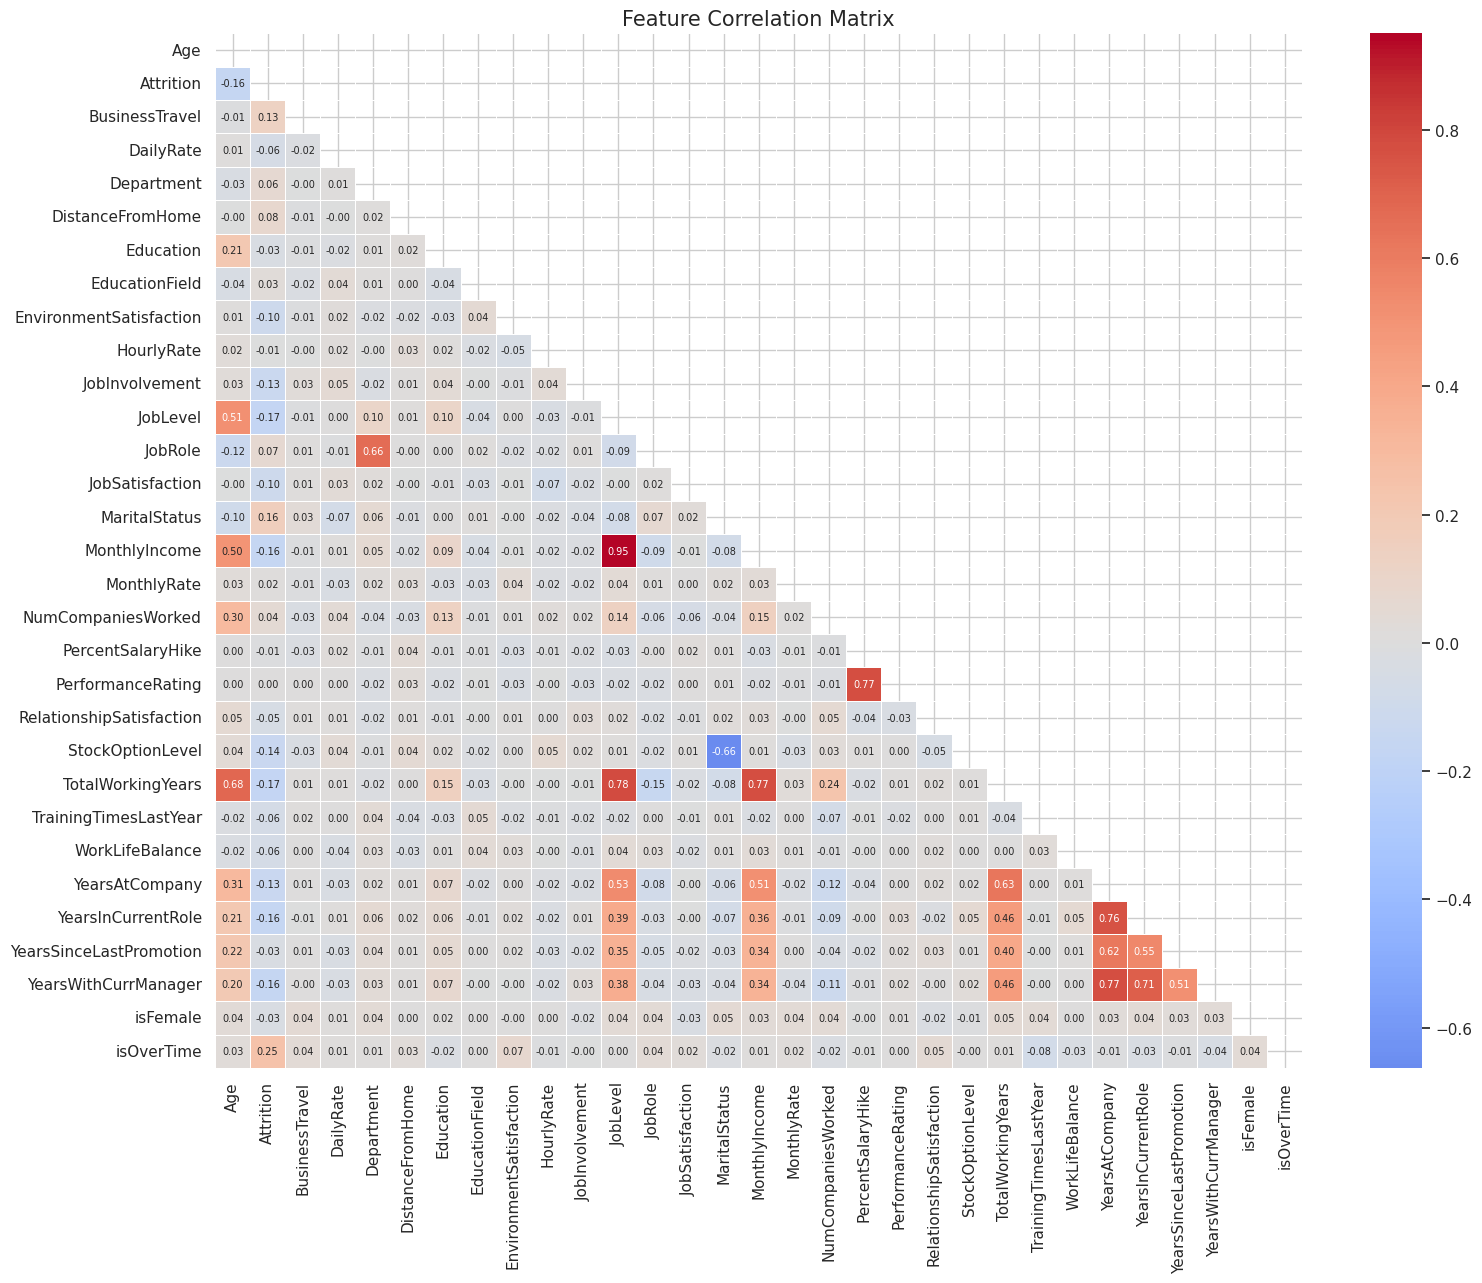


High Correlation Pairs (|r| > 0.75)
           Feature 1         Feature 2  Correlation
       MonthlyIncome          JobLevel     0.950300
   TotalWorkingYears          JobLevel     0.782208
   PerformanceRating PercentSalaryHike     0.773550
   TotalWorkingYears     MonthlyIncome     0.772893
YearsWithCurrManager    YearsAtCompany     0.769212
  YearsInCurrentRole    YearsAtCompany     0.758754


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Only show lower triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title('Feature Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.show()

# Flag high-correlation pairs (|r| > 0.75) — these may cause multicollinearity issues
print("\nHigh Correlation Pairs (|r| > 0.75)")
high_corr = (
    corr_matrix.abs()
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr = high_corr[high_corr['Correlation'] > 0.75].sort_values('Correlation', ascending=False)
print(high_corr.to_string(index=False))

#### 5. Outlier Detection

*Outliers in continuous features can skew model training. We use boxplots for the key numeric variables to visually flag extremes.*

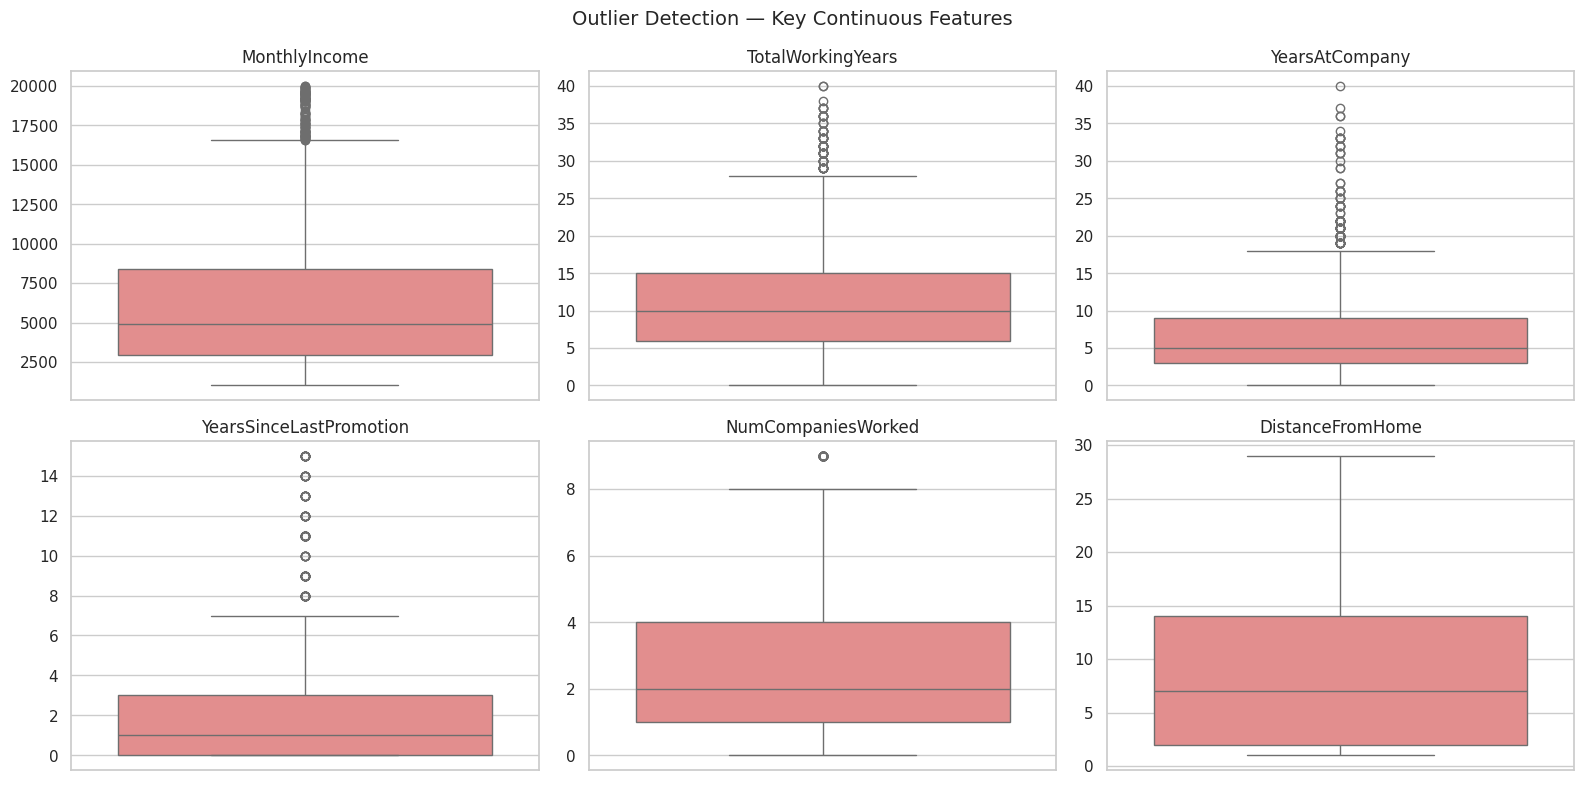


 Outlier Summary (IQR Method, beyond 1.5×IQR)
  MonthlyIncome: 114 outliers (7.8%)
  TotalWorkingYears: 63 outliers (4.3%)
  YearsAtCompany: 104 outliers (7.1%)
  YearsSinceLastPromotion: 107 outliers (7.3%)
  NumCompaniesWorked: 52 outliers (3.5%)
  DistanceFromHome: 0 outliers (0.0%)


In [ ]:
outlier_cols = ['MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'YearsSinceLastPromotion', 'NumCompaniesWorked', 'DistanceFromHome']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, outlier_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(f'{col}')
    ax.set_ylabel('')

plt.suptitle('Outlier Detection — Key Continuous Features', fontsize=14)
plt.tight_layout()
plt.show()

# IQR-based outlier count summary
print("\n Outlier Summary (IQR Method, beyond 1.5×IQR)")
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col}: {n_outliers} outliers ({n_outliers/len(df):.1%})")

# Feature Engineering

#### Reload Cleaned Data

In [ ]:
# Pull in Cleaned Dataframe from CSV
# CSV path
cleaned_csv_path = '/content/drive/MyDrive/ML1 - Final Project/employee_attrition_cleaned.csv'


# Import func
try:
    wip_fe_df = pd.read_csv(cleaned_csv_path) # named wip_fe_df as we're adding features to it
    print("CSV file imported successfully!")
    print(f"DataFrame shape: {wip_fe_df.shape}")
    print(wip_fe_df.head())
except FileNotFoundError:
    print(f"Error: The file '{cleaned_csv_path}' was not found. Please ensure it is in your Google Drive 'My Drive' folder.")
except Exception as e:
    print(f"An error occurred: {e}")


CSV file imported successfully!
DataFrame shape: (1470, 32)
   Age  Attrition  BusinessTravel  DailyRate  Department  DistanceFromHome  \
0   41          1             1.0       1102         2.0                 1   
1   49          0             2.0        279         1.0                 8   
2   37          1             1.0       1373         1.0                 2   
3   33          0             2.0       1392         1.0                 3   
4   27          0             1.0        591         1.0                 2   

   Education  EducationField  EnvironmentSatisfaction  HourlyRate  \
0          2             1.0                        2          94   
1          1             1.0                        3          61   
2          2             4.0                        4          92   
3          4             1.0                        4          56   
4          1             3.0                        1          40   

   JobInvolvement  JobLevel  JobRole  JobSatisfaction  M

#### Career Progression Features
-   **Promotion velocity Log** — `log(YearsAtCompany / (YearsSinceLastPromotion) + 1)`. How fast someone moves up the corporate ladder. A high ratio signals stagnation, while a low ratio signals a fast riser. Log added to address right-skew from EDA.
-   **Role tenure ratio** — `YearsInCurrentRole / YearsAtCompany`. How long someone has been in there role. Low values may indicate frequent lateral moves or instability, in comparison with the promotion velocity.
-   **Manager stability** — `YearsWithCurrManager / YearsAtCompany`. Employees who've had the same manager for most of their tenure may be more loyal (or conversely, more stuck).
-   **Career mobility proxy Log** — `NumCompaniesWorked / TotalWorkingYears`. Higher values could suggest a "job hopper" profile. Log added to fix skew.
-   **Prior Experience Years** — `TotalWorkingYears - YearsAtCompany`. Captures prior industry experience.

**Note 1:** Regular and Log based versions of features are created here. We only keep the Log based versions (when noted) in the final dataset, but both log and non-log versions are used in the EDA.

**Note 2:** +1 based denominator was added to RoleTenureRatio, ManagerStatbility, and CareerMobilityProxy to deal with NaN issues — some of these people had 0 full years at company or 0 working years, so the 1 base prevents DIV0 issues.

In [ ]:

# Promotion Velocity
wip_fe_df['PromotionVelocity'] = wip_fe_df['YearsAtCompany'] / (wip_fe_df['YearsSinceLastPromotion'] + 1)
wip_fe_df['PromotionVelocityLog'] = np.log1p(wip_fe_df['YearsAtCompany'] / (wip_fe_df['YearsSinceLastPromotion'] + 1))

# RoleTenureRatio
wip_fe_df['RoleTenureRatio'] = wip_fe_df['YearsInCurrentRole'] / (wip_fe_df['YearsAtCompany'] + 1)

# ManagerStability
wip_fe_df['ManagerStability'] = wip_fe_df['YearsWithCurrManager'] / (wip_fe_df['YearsAtCompany'] + 1)

# Career Mobility
wip_fe_df['CareerMobilityProxy'] = wip_fe_df['NumCompaniesWorked'] / (wip_fe_df['TotalWorkingYears'] + 1)
wip_fe_df['CareerMobilityProxyLog'] = np.log1p(wip_fe_df['NumCompaniesWorked'] / (wip_fe_df['TotalWorkingYears'] + 1))

# Prior Experience
wip_fe_df['PriorExperienceYears'] = wip_fe_df['TotalWorkingYears'] - wip_fe_df['YearsAtCompany']

#### Compensation Features
-   **Income per job level** — `MonthlyIncome / JobLevel`. Flags employees underpaid relative to their seniority.

NOTE: There are 2 other income features created in the "Peer-Relative Features" section. These must be created on testing data ONLY, which is why they aren't created here.


In [ ]:
# Income Per Job Level
wip_fe_df['IncomePerJobLevel'] = wip_fe_df["MonthlyIncome"] / wip_fe_df["JobLevel"].replace(0, np.nan)


#### Satisfaction Composite Features

-   **Overall satisfaction index** — average of `JobSatisfaction`, `EnvironmentSatisfaction`, `RelationshipSatisfaction`, and `WorkLifeBalance`. A single summary score for all satisfaction types we have.
-   **Satisfaction variance** — standard deviation across those four scores. High variance across the 4 categories could signal instability.
-   **Minimum satisfaction** — the single lowest score among the four categories. This could signal a potential "dealbreaker" for an employee.#

In [ ]:
# List Satisfaction columns
satisfaction_cols = [
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance",
]

# Satisfaction Index
wip_fe_df["SatisfactionIndex"] = wip_fe_df[satisfaction_cols].mean(axis=1)

# Satisfaction Variance
wip_fe_df["SatisfactionVariance"] = wip_fe_df[satisfaction_cols].std(axis=1)

# Minimum Satisfaction
wip_fe_df["MinimumSatisfaction"] = wip_fe_df[satisfaction_cols].min(axis=1)

#### Stress/Workload Indicators
-   **Commute burden** — `DistanceFromHome * isOverTime`. Long commute + overtime is a compounding stress signal
-   **Travel burden** — interact `BusinessTravel` with `DistanceFromHome` to capture total displacement.

In [ ]:
# Commute Burden
wip_fe_df["CommuteBurden"] = wip_fe_df["DistanceFromHome"] * wip_fe_df['isOverTime']


# Travel Burden
wip_fe_df["TravelBurden"] = wip_fe_df["BusinessTravel"] * wip_fe_df["DistanceFromHome"]

#### Tenure/Loyalty Features
-   **Early tenure flag** — `YearsAtCompany <= 2` (employees in their first two years churn at disproportionate rates).
-   **"Dead end" flag** — `YearsSinceLastPromotion >= 4` AND `JobLevel <= 2`. Identifies someone who is at a low-level and hasn't advanced in a while. I'd be curious to see how this interacts with age.
-   **Manager alignment Log** — `log1p(YearsWithCurrManager / YearsInCurrentRole)`. Values near 1 suggest the manager and role changed together, which could indicate a healthy (or unhealthy) transition depending on context. Log added to fix right skew.

**Note 1:** Regular and Log based versions of features are created here. We only keep the Log based versions (when noted) in the final dataset, but both log and non-log versions are used in the EDA.


In [ ]:
# Early Tenure Flag
wip_fe_df["EarlyTenureFlag"] = (wip_fe_df["YearsAtCompany"] <= 2).astype(int)

# Dead End Flag
wip_fe_df["DeadEndFlag"] = (
    (wip_fe_df["YearsSinceLastPromotion"] >= 4) & (wip_fe_df["JobLevel"] <= 2)
).astype(int)

# Manager Alignment
wip_fe_df['ManagerAlignment'] = wip_fe_df['YearsWithCurrManager'] / (wip_fe_df['YearsInCurrentRole'] + 1)
wip_fe_df['ManagerAlignmentLog'] = np.log1p(wip_fe_df['YearsWithCurrManager'] / (wip_fe_df['YearsInCurrentRole'] + 1))

#### Interaction Terms
-   `StockOptionLevel * YearsAtCompany` — golden handcuff proxy; vesting schedules often kick in around 3–4 years.

Note that these are not CamelCase, the _x_ indicates an interaction term.


In [ ]:
# Stock x Tenure
wip_fe_df["Stock_x_Tenure"] = wip_fe_df["StockOptionLevel"] * wip_fe_df["YearsAtCompany"]


#### **IMPORTANT** Split Train & Test
We need to split here so we can create the peer-relative features on training, then apply them to testing. Doing it in that order prevents data leakage.

We split the data 70/30 (train/test) with stratify=Attrition. The stratification ensures both splits preserve the dataset's natural attrition rate (~16%), rather than leaving the class distribution to chance. Without it, random sampling could produce a test set with meaningfully fewer or more attrition cases, making evaluation metrics like AUC and F1 unreliable.

The 70/30 ratio was chosen deliberately over the more common 80/20 default. With only ~1,470 rows and a minority class of ~237 attrition cases, an 80/20 split leaves only ~47 positive cases in the test set — too few for stable metric estimation. A 70/30 split yields ~71 positive test cases, which gives us more reliable evaluation without meaningfully sacrificing training data. Cross-validation during the modeling phase will further offset any cost of the smaller training set.

In [ ]:
from sklearn.model_selection import train_test_split

# Split to train/test
train_df, test_df = train_test_split(
    wip_fe_df,
    test_size=0.3,
    random_state=42,
    stratify=wip_fe_df["Attrition"]
)

# Sanity check — attrition rates should match closely
print(f"Train attrition rate: {train_df['Attrition'].mean():.3f}")
print(f"Test attrition rate:  {test_df['Attrition'].mean():.3f}")
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

Train attrition rate: 0.161
Test attrition rate:  0.161
Train size: 1029, Test size: 441


#### Create Peer-Relative Features
We need to fit these on training data and apply them to the test data to avoid leakage. That's why we split training/test here!

Features:
-   **Hike Disappointment** — a boolean flag or z-score for employees with `PercentSalaryHike` below the median within their `PerformanceRating` tier. Getting a weak raise despite strong performance is a known attrition driver.
-   **Income relative to peers** — mean-encode `MonthlyIncome` within `JobRole` and compute the deviation. Relative pay may be a better indicator than `MonthlyIncome` on its own.

In [ ]:
# Overall training fallbacks for unseen categories in test
overall_hike_median = train_df["PercentSalaryHike"].median()
overall_income_mean = train_df["MonthlyIncome"].mean()

# Hike disappointment
hike_medians = train_df.groupby("PerformanceRating")["PercentSalaryHike"].median()
for df in [train_df, test_df]:
    df["ExpectedHike"] = df["PerformanceRating"].map(hike_medians).fillna(overall_hike_median)
    df["HikeDisappointment"] = (df["PercentSalaryHike"] < df["ExpectedHike"]).astype(int)

# Income vs peers
role_income_means = train_df.groupby("JobRole")["MonthlyIncome"].mean()
for df in [train_df, test_df]:
    df["PeerIncomeMean"] = df["JobRole"].map(role_income_means).fillna(overall_income_mean)
    df["IncomeVsPeers"] = df["MonthlyIncome"] - df["PeerIncomeMean"]


# Feature Engineering EDA & Cleaning
Explore the engineered features, and clean them if needed.

### Ratio Features

NaN Audit — Ratio Features
  PromotionVelocity: 0 NaNs (0.0%)
  RoleTenureRatio: 0 NaNs (0.0%)
  ManagerStability: 0 NaNs (0.0%)
  CareerMobilityProxy: 0 NaNs (0.0%)
  ManagerAlignment: 0 NaNs (0.0%)



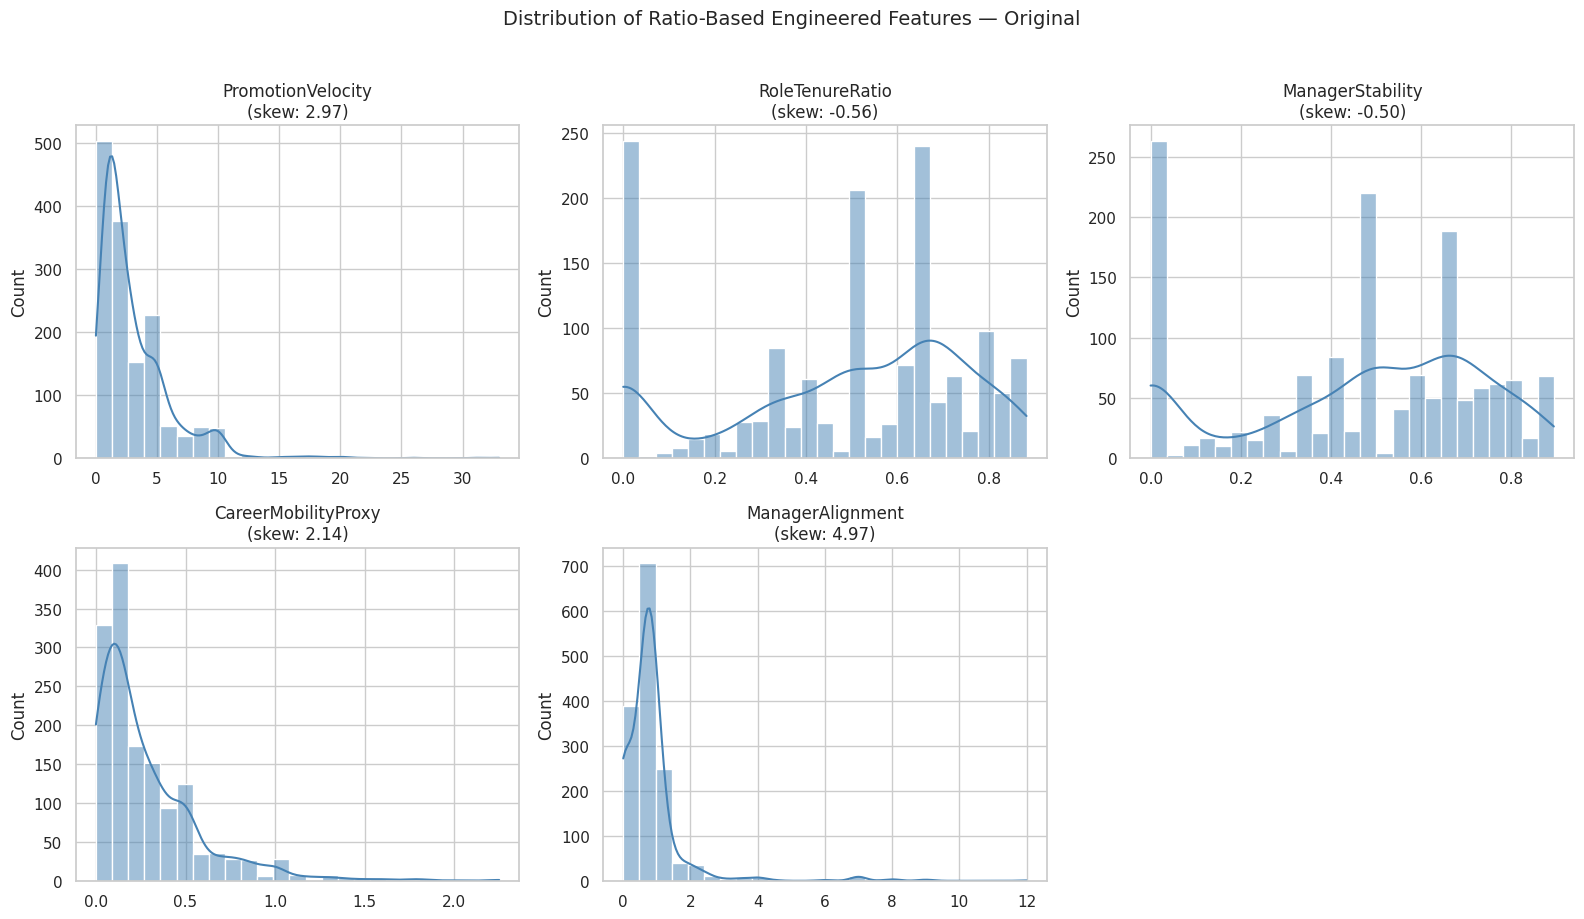

In [ ]:
ratio_features = [
    "PromotionVelocity",
    "RoleTenureRatio",
    "ManagerStability",
    "CareerMobilityProxy",
    "ManagerAlignment",
]

# Features to log-transform (right-skewed or heavy-tailed)
log_transform_features = [
    "PromotionVelocity",
    "CareerMobilityProxy",
    "ManagerAlignment",
]

# 1a. NaN audit — how many missing values did division by zero produce?
print("NaN Audit — Ratio Features")
print("=" * 40)
for col in ratio_features:
    n_nan = wip_fe_df[col].isna().sum()
    pct = n_nan / len(wip_fe_df)
    print(f"  {col}: {n_nan} NaNs ({pct:.1%})")
print()

# 1b. Apply log1p transforms
for col in log_transform_features:
    wip_fe_df[f"{col}Log"] = np.log1p(wip_fe_df[col])

# 1c. Distribution plots for ratio features (original)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, ratio_features):
    sns.histplot(wip_fe_df[col].dropna(), bins=25, kde=True, color="steelblue", ax=ax)
    ax.set_title(f"{col}\n(skew: {wip_fe_df[col].skew():.2f})")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

axes[-1].set_visible(False)  # hide unused 6th panel
plt.suptitle("Distribution of Ratio-Based Engineered Features — Original", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Re-review after log transformations

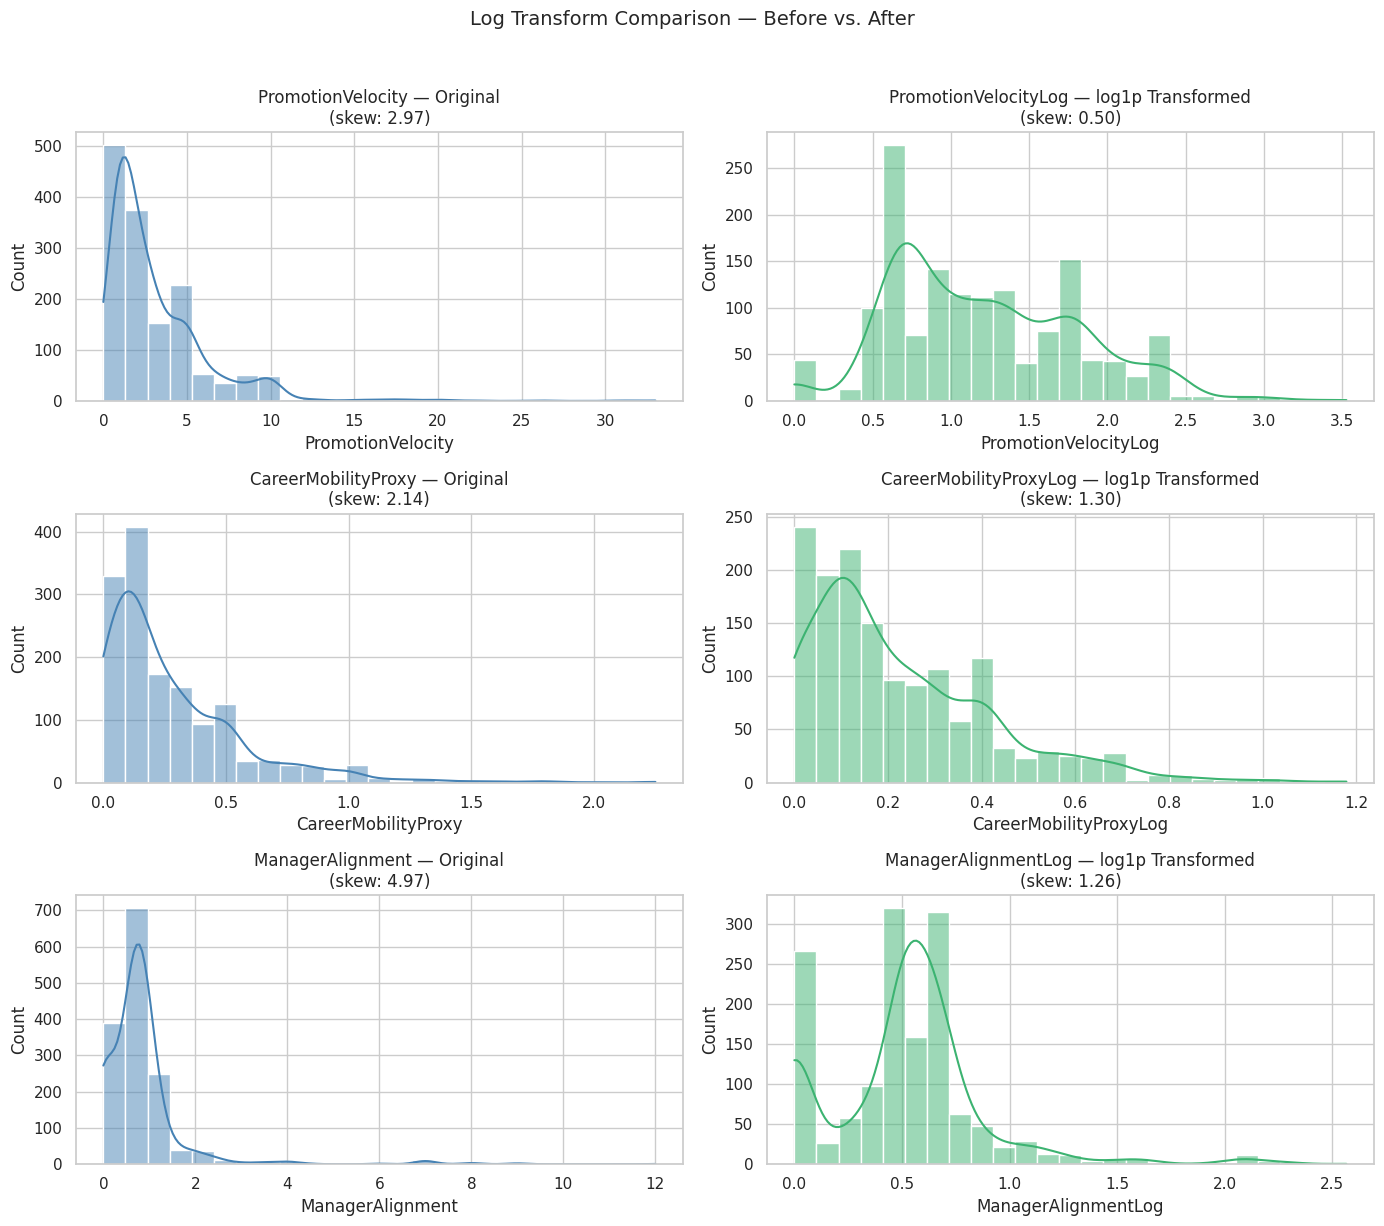

Skewness & Kurtosis — Ratio Features (Original + Log-Transformed)
                        Skewness  Kurtosis  High Skew (>|1|)  Heavy Tails (>3)
PromotionVelocity          2.969    15.843              True              True
RoleTenureRatio           -0.559    -0.844             False             False
ManagerStability          -0.496    -0.939             False             False
CareerMobilityProxy        2.136     6.717              True              True
ManagerAlignment           4.960    33.187              True              True
PromotionVelocityLog       0.501    -0.097             False             False
CareerMobilityProxyLog     1.297     1.884              True             False
ManagerAlignmentLog        1.262     4.529              True              True



In [ ]:
fig, axes = plt.subplots(len(log_transform_features), 2, figsize=(14, 4 * len(log_transform_features)))

for i, col in enumerate(log_transform_features):
    log_col = f"{col}Log"

    # Before
    sns.histplot(wip_fe_df[col].dropna(), bins=25, kde=True, color="steelblue", ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} — Original\n(skew: {wip_fe_df[col].skew():.2f})")
    axes[i, 0].set_ylabel("Count")

    # After
    sns.histplot(wip_fe_df[log_col].dropna(), bins=25, kde=True, color="mediumseagreen", ax=axes[i, 1])
    axes[i, 1].set_title(f"{log_col} — log1p Transformed\n(skew: {wip_fe_df[log_col].skew():.2f})")
    axes[i, 1].set_ylabel("Count")

plt.suptitle("Log Transform Comparison — Before vs. After", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 1e. Skewness & Kurtosis summary — original and log-transformed
all_ratio_cols = ratio_features + [f"{col}Log" for col in log_transform_features]
ratio_skew_kurt = pd.DataFrame({
    "Skewness": wip_fe_df[all_ratio_cols].apply(skew),
    "Kurtosis": wip_fe_df[all_ratio_cols].apply(kurtosis),
}).round(3)
ratio_skew_kurt["High Skew (>|1|)"] = ratio_skew_kurt["Skewness"].abs() > 1
ratio_skew_kurt["Heavy Tails (>3)"] = ratio_skew_kurt["Kurtosis"] > 3

print("Skewness & Kurtosis — Ratio Features (Original + Log-Transformed)")
print(ratio_skew_kurt.to_string())
print()

#### Ratio Feature NOTES
We'll drop the non-log versions of PromotionVelocity, CareerMobilityProxy, and ManagerAlignment, keeping the log-transformed versions instead. RoleTenureRatio and ManagerStability are kept as-is (skew within acceptable range). This drop is done in the cell below.

CareerMobilityProxyLog and ManagerAlignmentLog still show residual skew after transformation.
For tree-based models this is not a concern, but if using logistic regression or distance-based
models (e.g. KNN), ensure features are scaled and monitor whether the remaining tail values are
disproportionately influencing predictions. Given our small sample size, also verify
that extreme values are roughly balanced across train and test sets.


In [ ]:
# Drop columns mentioned above
for df in [train_df, test_df, wip_fe_df]:
    df.drop(columns=[
        "PromotionVelocity",
        "CareerMobilityProxy",
        "ManagerAlignment",
    ], inplace=True)

### Flag Features

/tmp/ipython-input-3296445251.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Blues_d")
/tmp/ipython-input-3296445251.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Blues_d")


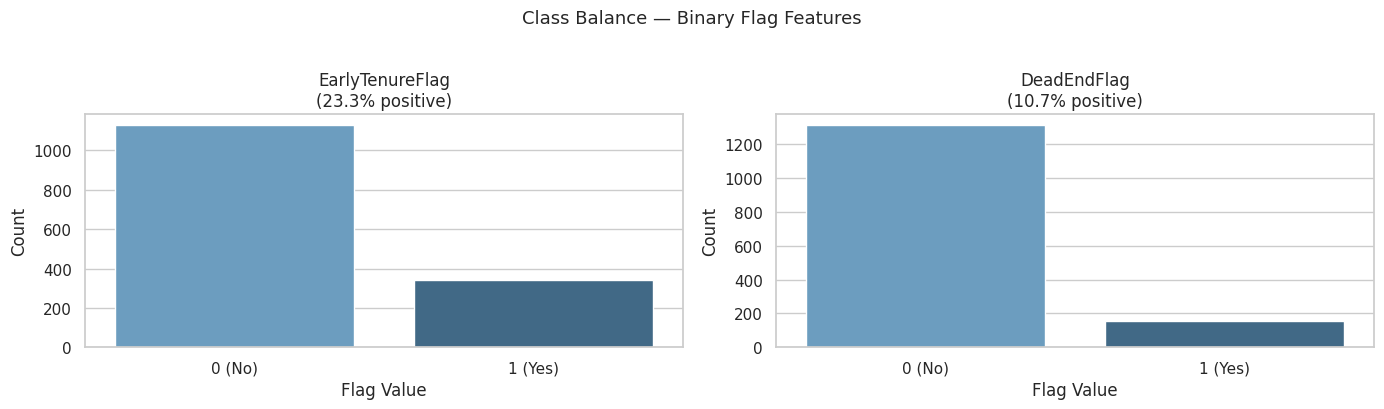

Flag Feature Positive Rates
  EarlyTenureFlag: 23.3% positive
  DeadEndFlag: 10.7% positive



In [ ]:
# List of flag features to analyze
flag_features = ["EarlyTenureFlag", "DeadEndFlag"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot
for ax, col in zip(axes, flag_features):
    counts = wip_fe_df[col].value_counts().sort_index()
    pct_positive = wip_fe_df[col].mean()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="Blues_d")
    ax.set_title(f"{col}\n({pct_positive:.1%} positive)")
    ax.set_xlabel("Flag Value")
    ax.set_ylabel("Count")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["0 (No)", "1 (Yes)"])

plt.suptitle("Class Balance — Binary Flag Features", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Flag Feature Positive Rates")
print("=" * 40)
for col in flag_features:
    print(f"  {col}: {wip_fe_df[col].mean():.1%} positive")
print()


#### Flag Feature NOTES
Nothing too crazy here — results are a bit imbalanced, but nothing to be overly concerned about for modeling.

### Peer-Relative Features

/tmp/ipython-input-3386715684.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PerformanceRating", y="HikeDisappointment",


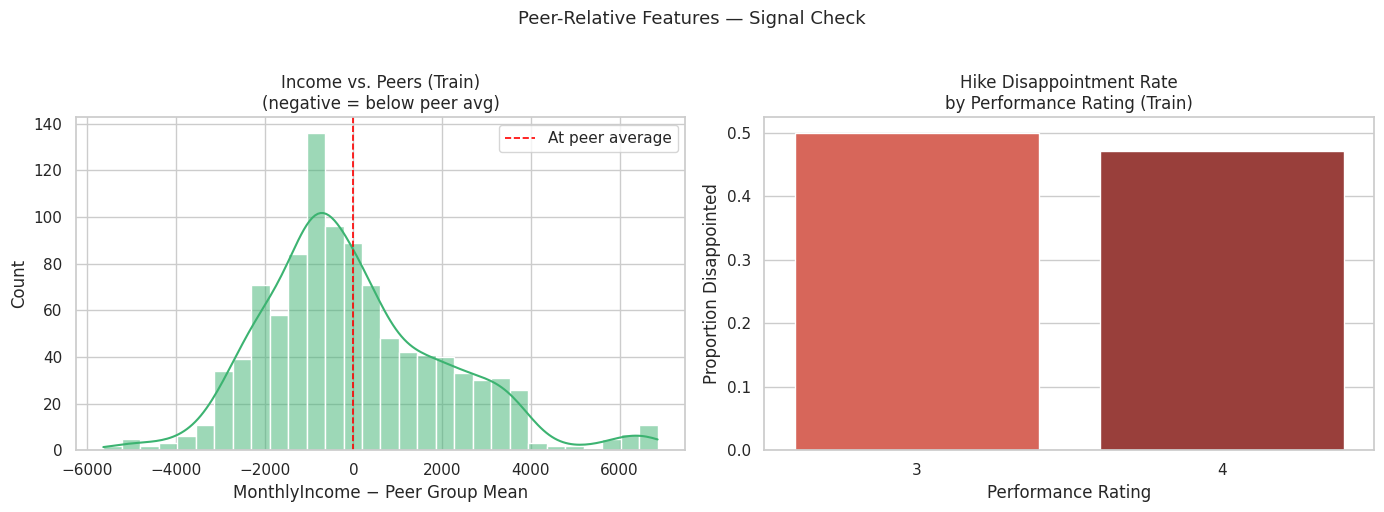

Peer-Relative Feature Summaries (Train)
  IncomeVsPeers — mean: -0.0, std: 2066.0
  HikeDisappointment — 49.6% flagged



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3a. Income vs. Peers
sns.histplot(train_df["IncomeVsPeers"].dropna(), bins=30, kde=True,
             color="mediumseagreen", ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.2, label="At peer average")
axes[0].set_title("Income vs. Peers (Train)\n(negative = below peer avg)")
axes[0].set_xlabel("MonthlyIncome − Peer Group Mean")
axes[0].set_ylabel("Count")
axes[0].legend()

# 3b. Hike disappointment — rate by PerformanceRating group
hike_by_perf = (
    train_df.groupby("PerformanceRating")["HikeDisappointment"]
    .mean()
    .reset_index()
)
sns.barplot(x="PerformanceRating", y="HikeDisappointment",
            data=hike_by_perf, palette="Reds_d", ax=axes[1])
axes[1].set_title("Hike Disappointment Rate\nby Performance Rating (Train)")
axes[1].set_xlabel("Performance Rating")
axes[1].set_ylabel("Proportion Disappointed")

plt.suptitle("Peer-Relative Features — Signal Check", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Peer-Relative Feature Summaries (Train)")
print("=" * 40)
print(f"  IncomeVsPeers — mean: {train_df['IncomeVsPeers'].mean():.1f}, "
      f"std: {train_df['IncomeVsPeers'].std():.1f}")
print(f"  HikeDisappointment — {train_df['HikeDisappointment'].mean():.1%} flagged")
print()

#### Peer-Relative Feature NOTES
IncomeVsPeers is pretty clean. Hike Disappointment may be a feature to drop if it isn't important, since it's only a two-group variable.

### Satisfaction Composite Features

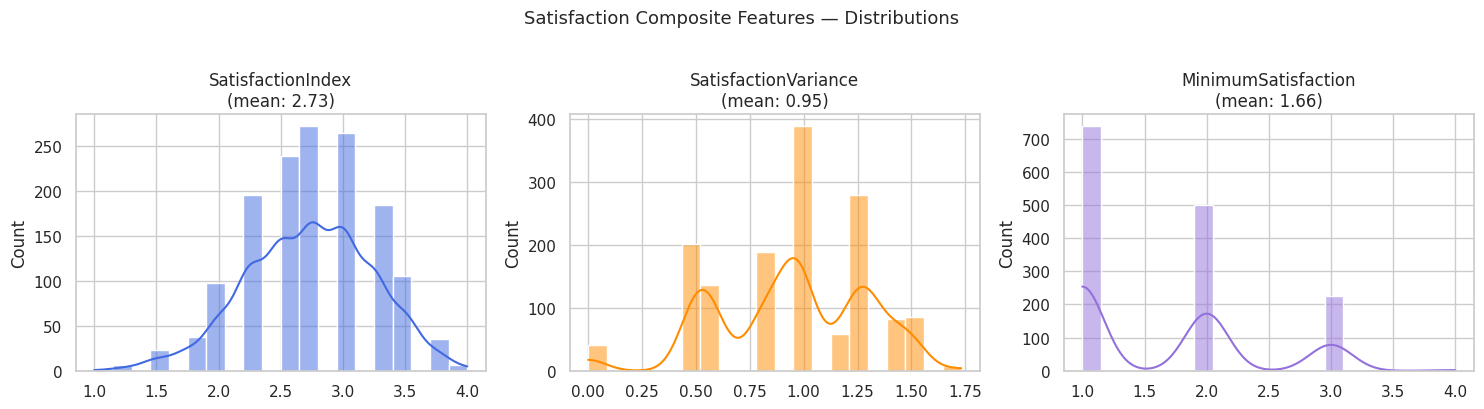

In [ ]:
satisfaction_engineered = ["SatisfactionIndex", "SatisfactionVariance", "MinimumSatisfaction"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = ["royalblue", "darkorange", "mediumpurple"]
for ax, col, color in zip(axes, satisfaction_engineered, colors):
    sns.histplot(wip_fe_df[col].dropna(), bins=20, kde=True, color=color, ax=ax)
    ax.set_title(f"{col}\n(mean: {wip_fe_df[col].mean():.2f})")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.suptitle("Satisfaction Composite Features — Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


#### Satisfaction Composite NOTES
The only noteworth thing here is that SatisfactionIndex and MinimumSatisfaction will be slightly correlated by designed, since they're both derived from the same column set

### Updated Correlation Heatmap

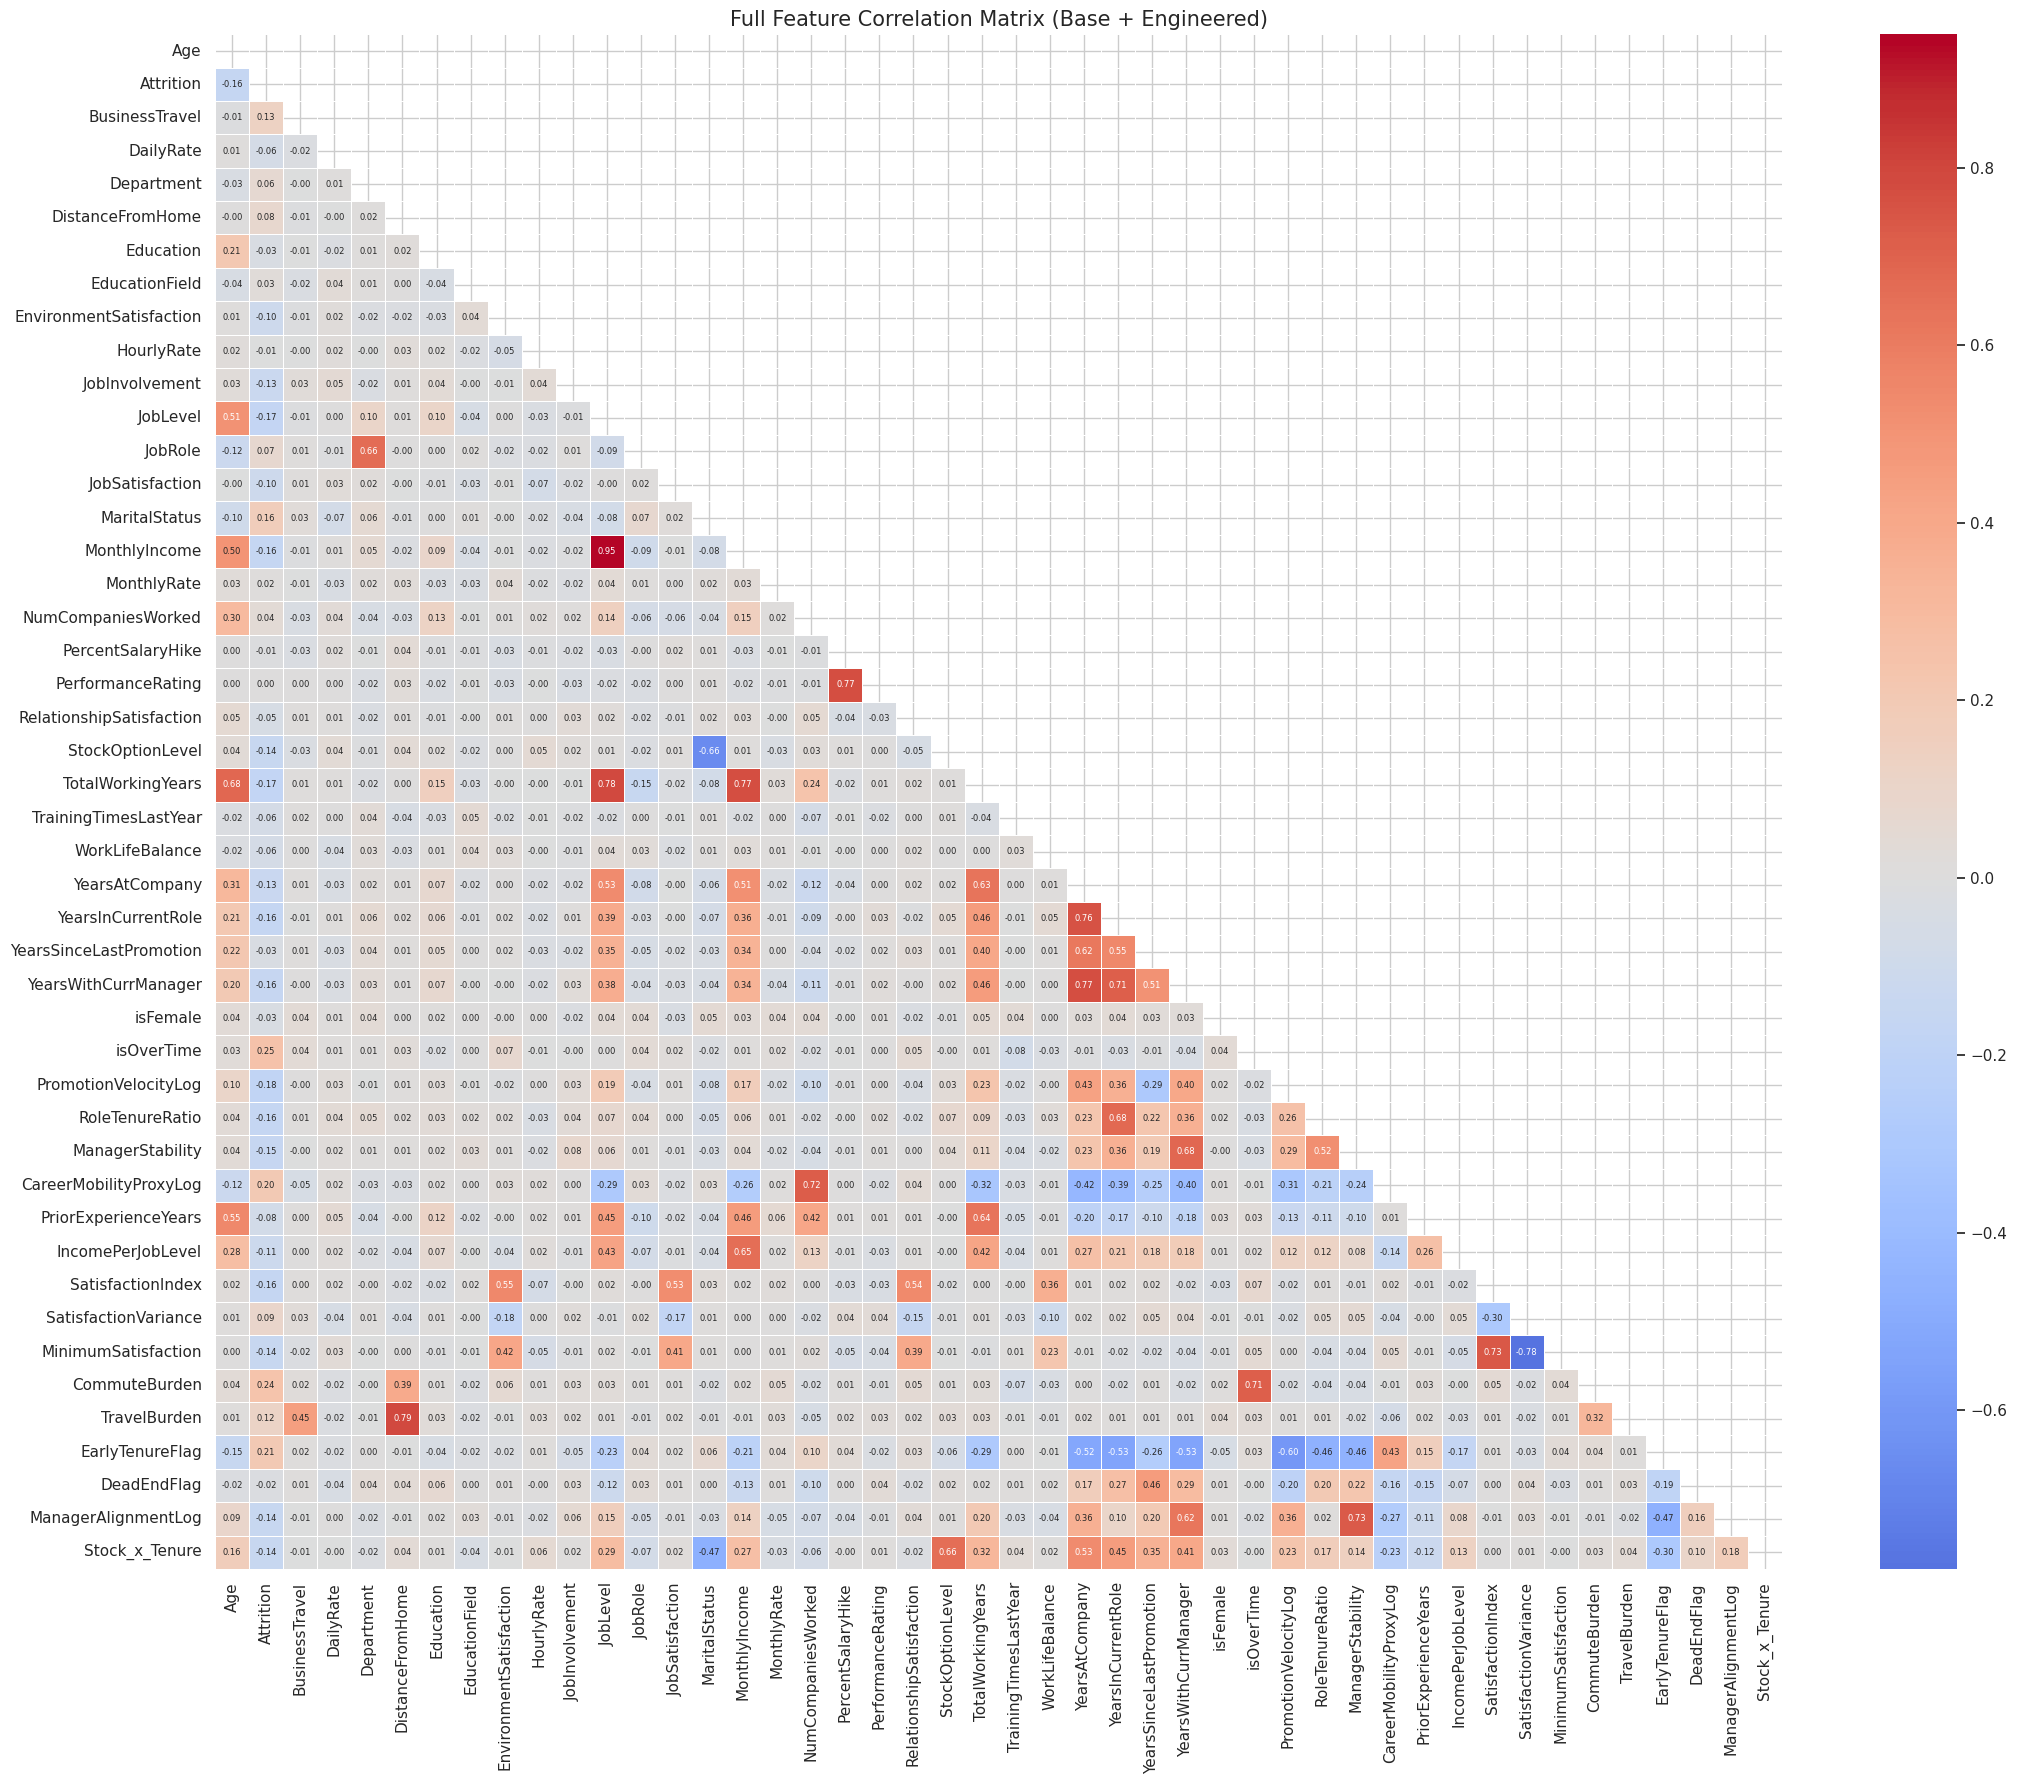

High Correlation Pairs (|r| > 0.75) — Full Feature Set
           Feature 1            Feature 2  Correlation
       MonthlyIncome             JobLevel     0.950300
        TravelBurden     DistanceFromHome     0.793014
   TotalWorkingYears             JobLevel     0.782208
 MinimumSatisfaction SatisfactionVariance     0.778680
   PerformanceRating    PercentSalaryHike     0.773550
   TotalWorkingYears        MonthlyIncome     0.772893
YearsWithCurrManager       YearsAtCompany     0.769212
  YearsInCurrentRole       YearsAtCompany     0.758754



In [ ]:
# Select all numeric columns from wip_fe_df (pre-split, row-wise features only)
# Peer-relative features are on train_df — we'll add them separately below
engineered_cols = ratio_features + flag_features + satisfaction_engineered + [
    "IncomePerJobLevel",
    "CommuteBurden",
    "TravelBurden",
    "PriorExperienceYears",
    "Age_x_Companies",
    "Involvement_x_Satisfaction",
    "Stock_x_Tenure",
]

# Pull base + engineered feature correlation
all_numeric = wip_fe_df.select_dtypes(include=[np.number])
corr_matrix = all_numeric.corr()

plt.figure(figsize=(22, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    annot_kws={"size": 6},
)
plt.title("Full Feature Correlation Matrix (Base + Engineered)", fontsize=15)
plt.tight_layout()
plt.show()

# Flag high-correlation pairs (|r| > 0.75)
print("High Correlation Pairs (|r| > 0.75) — Full Feature Set")
print("=" * 55)
high_corr = (
    corr_matrix.abs()
    .where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]
high_corr = high_corr[high_corr["Correlation"] > 0.75].sort_values(
    "Correlation", ascending=False
)
print(high_corr.to_string(index=False))
print()

#### Correlation Heatmap NOTES
After dropping the non-log originals and the two redundant interaction terms, the high-correlation pair count reduced from 12 to 7. All remaining pairs are pre-existing relationships not introduced by feature engineering.

**Pre-existing, expected relationships — no action needed:**
- `MonthlyIncome` vs `JobLevel` (r=0.54) — seniority drives pay
- `TotalWorkingYears` vs `JobLevel` (r=0.78) and `TotalWorkingYears` vs `MonthlyIncome` (r=0.77) — experience correlates with seniority and pay
- `PerformanceRating` vs `PercentSalaryHike` (r=0.77) — strong performers get bigger raises
- `YearsWithCurrManager` vs `YearsAtCompany` (r=0.77) — longer tenure means more time with current manager
- `TravelBurden` vs `DistanceFromHome` (r=0.79) — expected, as `TravelBurden = BusinessTravel × DistanceFromHome`

**One to monitor:**
- `MinimumSatisfaction` vs `SatisfactionVariance` (r=0.81) — the only remaining engineered pair. Both are derived from the same four satisfaction columns. Monitor feature importance during modeling and drop one if both show weak signal.

### Interaction Term Analysis

In [ ]:
# Check if interaction/ratio terms are adding signal beyond their source variables.
# We'd expect high correlation with sources — the question is how high.

interaction_check = {
    "Stock_x_Tenure":           ["StockOptionLevel", "YearsAtCompany"],
    "PromotionVelocityLog":     ["YearsAtCompany", "YearsSinceLastPromotion"],
    "RoleTenureRatio":          ["YearsInCurrentRole", "YearsAtCompany"],
    "ManagerStability":         ["YearsWithCurrManager", "YearsAtCompany"],
}

print("Interaction / Ratio Terms — Correlation with Source Variables")
print("=" * 60)
for engineered, sources in interaction_check.items():
    if engineered not in wip_fe_df.columns:
        continue
    for src in sources:
        r = wip_fe_df[engineered].corr(wip_fe_df[src])
        flag = "  ← HIGH" if abs(r) > 0.75 else ""
        print(f"  {engineered} vs {src}: r = {r:.3f}{flag}")
    print()

Interaction / Ratio Terms — Correlation with Source Variables
  Stock_x_Tenure vs StockOptionLevel: r = 0.658
  Stock_x_Tenure vs YearsAtCompany: r = 0.532

  PromotionVelocityLog vs YearsAtCompany: r = 0.431
  PromotionVelocityLog vs YearsSinceLastPromotion: r = -0.290

  RoleTenureRatio vs YearsInCurrentRole: r = 0.678
  RoleTenureRatio vs YearsAtCompany: r = 0.226

  ManagerStability vs YearsWithCurrManager: r = 0.682
  ManagerStability vs YearsAtCompany: r = 0.233



### Interaction Term Notes
Nothing concerning here, all correlation coefficients under 0.75

## Feature Engineering EDA Summary

### Engineered features in final set
| Feature | Type |
|---|---|
| `PromotionVelocityLog` | Ratio (log-transformed) |
| `RoleTenureRatio` | Ratio |
| `ManagerStability` | Ratio |
| `CareerMobilityProxyLog` | Ratio (log-transformed) |
| `ManagerAlignmentLog` | Ratio (log-transformed) |
| `PriorExperienceYears` | Arithmetic |
| `IncomePerJobLevel` | Ratio |
| `SatisfactionIndex` | Composite |
| `SatisfactionVariance` | Composite |
| `MinimumSatisfaction` | Composite |
| `CommuteBurden` | Interaction |
| `TravelBurden` | Interaction |
| `EarlyTenureFlag` | Binary flag |
| `DeadEndFlag` | Binary flag |
| `Stock_x_Tenure` | Interaction |
| `IncomeVsPeers` | Peer-relative |
| `HikeDisappointment` | Peer-relative (monitor) |

**All base features retained except those dropped during initial cleaning.**


**Skew caution note:** `CareerMobilityProxyLog` and `ManagerAlignmentLog` still show residual skew after transformation. For tree-based models this is not a concern, but if using logistic regression or distance-based models (e.g. KNN), ensure features are scaled and monitor whether the remaining tail values are disproportionately influencing predictions. Given the small sample size, also verify that extreme values are roughly balanced across train and test sets.

# Export Test and Train Data
Export train and test data to CSV. The initial split was done at the end of the Feature Engineering section (cell "IMPORTANT Split Train & Test")

In [ ]:
# Train to CSV
train_csv_path = '/content/drive/MyDrive/ML1 - Final Project/employee_attrition_TRAIN_DATASET.csv'
train_df.to_csv(train_csv_path, index=False)

# Test to CSV
test_csv_path = '/content/drive/MyDrive/ML1 - Final Project/employee_attrition_TEST_DATASET.csv'
test_df.to_csv(test_csv_path, index=False)